NameError: name '__file__' is not defined

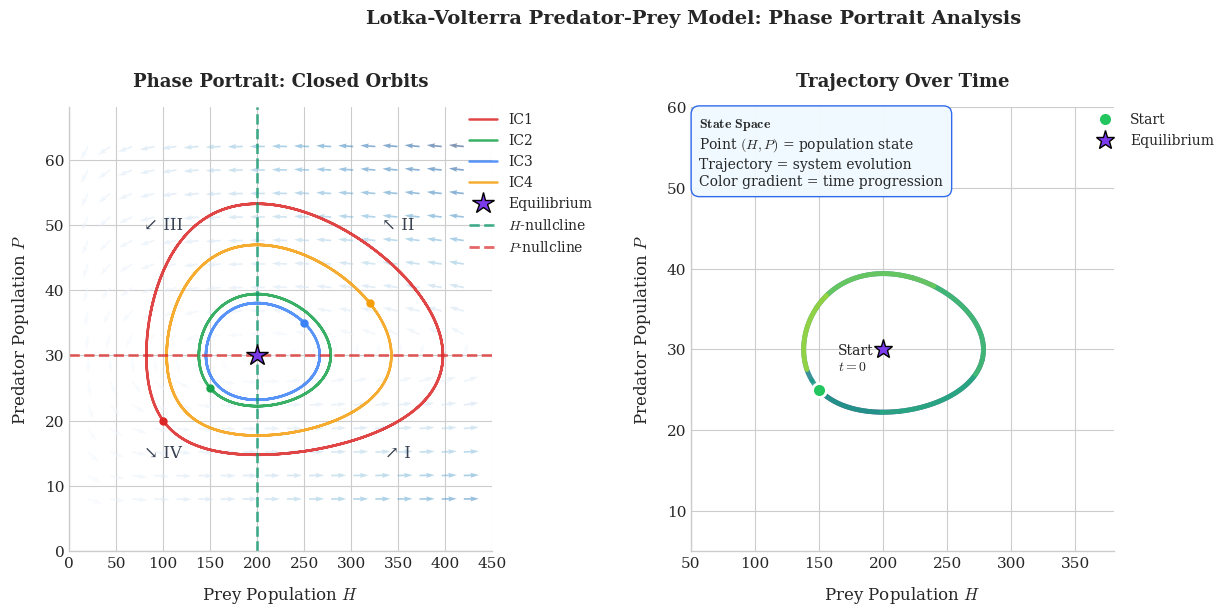

In [1]:
"""
Lotka-Volterra Phase Portrait Illustration
Shows closed orbits and equilibrium points in predator-prey dynamics
"""
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
from pathlib import Path

# Professional styling - consistent across all weeks
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['legend.fontsize'] = 10

# Consistent color scheme
COLORS = {
    'primary': '#2563eb',
    'secondary': '#dc2626',
    'tertiary': '#059669',
    'accent': '#7c3aed',
    'orange': '#f59e0b',
    'box_bg': '#f0f9ff',
    'box_edge': '#2563eb'
}

def lotka_volterra(state, t, alpha, beta, lambd, gamma):
    """Lotka-Volterra predator-prey equations."""
    H, P = state
    dHdt = alpha * H - beta * H * P
    dPdt = lambd * H * P - gamma * P
    return [dHdt, dPdt]

def create_phase_portrait():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=100)

    # Parameters (from Week 8 lesson)
    alpha = 0.15   # Prey birth rate
    beta = 0.005   # Predation rate
    lambd = 0.0005 # Predator efficiency
    gamma = 0.10   # Predator death rate

    # Equilibrium points
    H_star = gamma / lambd  # = 200
    P_star = alpha / beta   # = 30

    # === Panel 1: Phase Portrait ===
    ax1 = axes[0]

    # Create direction field
    H_range = np.linspace(20, 420, 18)
    P_range = np.linspace(8, 62, 16)
    H_grid, P_grid = np.meshgrid(H_range, P_range)

    dH = alpha * H_grid - beta * H_grid * P_grid
    dP = lambd * H_grid * P_grid - gamma * P_grid

    # Normalize for quiver plot
    magnitude = np.sqrt(dH**2 + dP**2)
    magnitude[magnitude == 0] = 1
    dH_norm = dH / magnitude
    dP_norm = dP / magnitude

    # Plot direction field
    ax1.quiver(H_grid, P_grid, dH_norm, dP_norm, magnitude,
               cmap='Blues', alpha=0.5, scale=28, width=0.004)

    # Plot several trajectories with different initial conditions
    t = np.linspace(0, 150, 2000)

    initial_conditions = [
        (100, 20, '#dc2626', 'IC1'),
        (150, 25, '#16a34a', 'IC2'),
        (250, 35, '#3b82f6', 'IC3'),
        (320, 38, '#f59e0b', 'IC4'),
    ]

    for H0, P0, color, label in initial_conditions:
        solution = odeint(lotka_volterra, [H0, P0], t,
                         args=(alpha, beta, lambd, gamma))
        ax1.plot(solution[:, 0], solution[:, 1], color=color,
                linewidth=1.8, alpha=0.85, label=label)
        ax1.plot(H0, P0, 'o', color=color, markersize=5, zorder=5)

    # Mark equilibrium point
    ax1.plot(H_star, P_star, '*', markersize=16, color=COLORS['accent'],
             markeredgecolor='black', markeredgewidth=1, zorder=10, label='Equilibrium')

    # Draw nullclines
    ax1.axvline(x=H_star, color=COLORS['tertiary'], linestyle='--', linewidth=2, alpha=0.7, label='$H$-nullcline')
    ax1.axhline(y=P_star, color=COLORS['secondary'], linestyle='--', linewidth=2, alpha=0.7, label='$P$-nullcline')

    # Direction labels in quadrants (positioned to avoid overlap)
    ax1.text(350, 15, '↗ I', fontsize=12, ha='center', va='center', color='#374151')
    ax1.text(350, 50, '↖ II', fontsize=12, ha='center', va='center', color='#374151')
    ax1.text(100, 50, '↙ III', fontsize=12, ha='center', va='center', color='#374151')
    ax1.text(100, 15, '↘ IV', fontsize=12, ha='center', va='center', color='#374151')

    # Legend outside plot area
    ax1.legend(loc='upper right', bbox_to_anchor=(1.25, 1), borderaxespad=0.)

    ax1.set_xlabel('Prey Population $H$', fontsize=12, labelpad=10)
    ax1.set_ylabel('Predator Population $P$', fontsize=12, labelpad=10)
    ax1.set_title('Phase Portrait: Closed Orbits', fontsize=13, fontweight='bold', pad=15)
    ax1.set_xlim(0, 450)
    ax1.set_ylim(0, 68)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # === Panel 2: State space concept ===
    ax2 = axes[1]

    # Single trajectory to illustrate the concept
    t = np.linspace(0, 100, 1500)
    H0, P0 = 150, 25
    solution = odeint(lotka_volterra, [H0, P0], t, args=(alpha, beta, lambd, gamma))

    # Color segments to show time progression
    n_segments = 10
    segment_length = len(t) // n_segments
    colors_time = plt.cm.viridis(np.linspace(0.15, 0.85, n_segments))

    for i in range(n_segments):
        start = i * segment_length
        end = (i + 1) * segment_length + 1
        ax2.plot(solution[start:end, 0], solution[start:end, 1],
                color=colors_time[i], linewidth=3.5, alpha=0.9)

    # Mark start
    ax2.plot(H0, P0, 'o', markersize=10, color='#22c55e',
             markeredgecolor='white', markeredgewidth=2, zorder=10, label='Start')
    ax2.text(H0 + 15, P0 + 2, 'Start\n$t=0$', fontsize=10, va='bottom')

    # Equilibrium point
    ax2.plot(H_star, P_star, '*', markersize=14, color=COLORS['accent'],
             markeredgecolor='black', markeredgewidth=1, zorder=10, label='Equilibrium')

    # Annotation explaining state space
    textstr = (r'$\mathbf{State\ Space}$' + '\n' +
               'Point $(H, P)$ = population state\n' +
               'Trajectory = system evolution\n' +
               'Color gradient = time progression')
    props = dict(boxstyle='round,pad=0.6', facecolor=COLORS['box_bg'],
                 edgecolor=COLORS['box_edge'], alpha=0.95)
    ax2.text(0.02, 0.98, textstr, transform=ax2.transAxes, fontsize=10,
             verticalalignment='top', bbox=props, linespacing=1.3)

    # Legend outside plot area
    ax2.legend(loc='upper right', bbox_to_anchor=(1.25, 1), borderaxespad=0.)

    ax2.set_xlabel('Prey Population $H$', fontsize=12, labelpad=10)
    ax2.set_ylabel('Predator Population $P$', fontsize=12, labelpad=10)
    ax2.set_title('Trajectory Over Time', fontsize=13, fontweight='bold', pad=15)
    ax2.set_xlim(50, 380)
    ax2.set_ylim(5, 60)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # Overall title
    fig.suptitle('Lotka-Volterra Predator-Prey Model: Phase Portrait Analysis',
                 fontsize=14, fontweight='bold', y=1.02)

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    return fig

if __name__ == '__main__':
    fig = create_phase_portrait()
    output_path = Path(__file__).parent / 'lotka_volterra_phase.svg'
    fig.savefig(output_path, format='svg', bbox_inches='tight', transparent=False)
    print(f"Saved to {output_path}")
    plt.close()
